# 6.17 - CertCF 2D Adult PCA Coverage Diagnostics

This notebook mirrors the spirit of `6.16`, but instead of a synthetic dataset we use a **2D PCA projection of Adult**.

Goals:
- inspect CertCF coverage on a real tabular dataset in a visual 2D sandbox
- compare how the atlas changes with different `eps_alpha` values
- check certified-union overlap explicitly
- study a few counterfactual queries in the projected plane

Important caveat:
- this is a **diagnostic projection notebook**
- certification here lives in the **2D PCA space**, not in the full original Adult feature space


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from matplotlib.colors import ListedColormap
from torch.utils.data import TensorDataset
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from certcf import CertCFAtlas, NearestOppositeClassClearanceStrategy
from certcf.geometry.operations import compute_overlap_matrix
from certcf.visualization.plotting import plot_polytopes, plot_overlap_heatmap
from models.classifiers import SimpleClassifier
from training.datamodules.adult import AdultDataModule

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.title_fontsize': 9,
    'figure.titlesize': 12,
})
np.set_printoptions(precision=4, suppress=True)

torch.set_grad_enabled(True)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print({'device': str(DEVICE), 'seed': SEED})


{'device': 'cuda', 'seed': 42}


## Load Adult and project to 2D

We load the standard preprocessed Adult features from the repo datamodule, then fit a simple **2D PCA** on the train split only.

This keeps the notebook aligned with the repo preprocessing while still giving us a plane we can visualize.


In [2]:
DATASET_CFG = {
    'filepath': str(ROOT / 'data' / 'Adult' / 'raw.parquet'),
    'batch_size': 256,
    'val_fraction': 0.1,
    'test_fraction': 0.1,
    'seed': SEED,
    'num_workers': 0,
}


def fit_pca_2d(x_train: np.ndarray):
    mean = x_train.mean(axis=0, keepdims=True).astype(np.float32)
    centered = x_train.astype(np.float32) - mean
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    components = vt[:2].astype(np.float32)
    explained_variance = (singular_values ** 2) / max(centered.shape[0] - 1, 1)
    explained_ratio = (explained_variance[:2] / explained_variance.sum()).astype(np.float32)
    return mean, components, explained_ratio


def transform_pca(x: np.ndarray, mean: np.ndarray, components: np.ndarray) -> np.ndarray:
    return ((x.astype(np.float32) - mean) @ components.T).astype(np.float32)


dm = AdultDataModule(**DATASET_CFG)
dm.setup()

X_TRAIN_FULL, Y_TRAIN_TRUE = [t.numpy() for t in dm.train_ds.tensors]
X_TEST_FULL, Y_TEST_TRUE = [t.numpy() for t in dm.test_ds.tensors]

PCA_MEAN, PCA_COMPONENTS, PCA_EXPLAINED = fit_pca_2d(X_TRAIN_FULL)
X_TRAIN = transform_pca(X_TRAIN_FULL, PCA_MEAN, PCA_COMPONENTS)
X_TEST = transform_pca(X_TEST_FULL, PCA_MEAN, PCA_COMPONENTS)

print({
    'train_shape_full': tuple(X_TRAIN_FULL.shape),
    'test_shape_full': tuple(X_TEST_FULL.shape),
    'train_shape_2d': tuple(X_TRAIN.shape),
    'test_shape_2d': tuple(X_TEST.shape),
    'train_class_counts': {int(c): int((Y_TRAIN_TRUE == c).sum()) for c in np.unique(Y_TRAIN_TRUE)},
    'test_class_counts': {int(c): int((Y_TEST_TRUE == c).sum()) for c in np.unique(Y_TEST_TRUE)},
    'pca_explained_ratio': [float(v) for v in PCA_EXPLAINED],
    'pca_explained_ratio_sum': float(PCA_EXPLAINED.sum()),
})


{'train_shape_full': (36178, 104), 'test_shape_full': (4522, 104), 'train_shape_2d': (36178, 2), 'test_shape_2d': (4522, 2), 'train_class_counts': {0: 27224, 1: 8954}, 'test_class_counts': {0: 3385, 1: 1137}, 'pca_explained_ratio': [0.15252994000911713, 0.10873151570558548], 'pca_explained_ratio_sum': 0.2612614631652832}


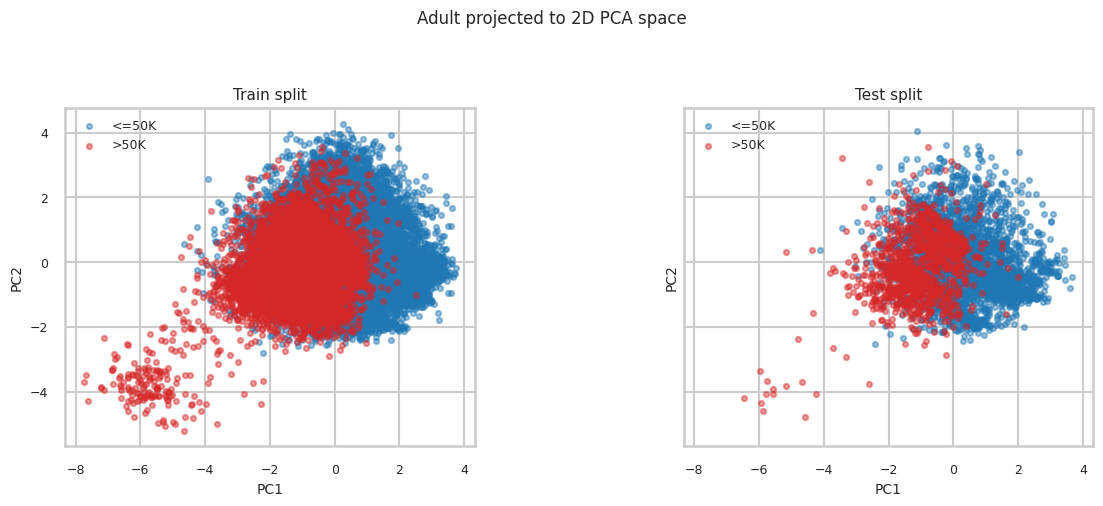

In [3]:
def plot_dataset(x_train, y_train, x_test, y_test, title='Adult projected to 2D PCA space'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
    palette = {0: '#1f77b4', 1: '#d62728'}
    labels = {0: '<=50K', 1: '>50K'}
    for ax, x, y, split in [
        (axes[0], x_train, y_train, 'Train'),
        (axes[1], x_test, y_test, 'Test'),
    ]:
        for cls in sorted(np.unique(y)):
            mask = y == cls
            ax.scatter(x[mask, 0], x[mask, 1], s=14, alpha=0.45, c=palette[cls], label=labels[cls])
        ax.set_title(f'{split} split', fontsize=11)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.legend(frameon=False, fontsize=9)
        ax.set_aspect('equal')
    fig.suptitle(title, y=1.02, fontsize=12)
    fig.tight_layout()
    return fig, axes


plot_dataset(X_TRAIN, Y_TRAIN_TRUE, X_TEST, Y_TEST_TRUE)
plt.show()


## Train a small 2D classifier

As in `6.16`, we train a compact local classifier directly in the 2D space.

This keeps the diagnostic self-contained and makes the resulting atlas interpretable in the PCA plane.


In [4]:
TRAIN_CFG = {
    'hidden_dims': (64, 32),
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'epochs': 300,
    'batch_size': 512,
}


def train_classifier(x_train, y_train, x_test, y_test, cfg, device=DEVICE):
    model = SimpleClassifier(input_dim=2, hidden_dims=cfg['hidden_dims'], num_classes=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss()

    x_train_t = torch.from_numpy(x_train).float().to(device)
    y_train_t = torch.from_numpy(y_train).long().to(device)
    x_test_t = torch.from_numpy(x_test).float().to(device)
    y_test_t = torch.from_numpy(y_test).long().to(device)

    for epoch in range(cfg['epochs']):
        model.train()
        perm = torch.randperm(len(x_train_t), device=device)
        for start in range(0, len(x_train_t), cfg['batch_size']):
            idx = perm[start:start + cfg['batch_size']]
            logits = model(x_train_t[idx])
            loss = criterion(logits, y_train_t[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if epoch in {0, 49, 99, 199, cfg['epochs'] - 1}:
            model.eval()
            train_acc = (model(x_train_t).argmax(dim=1) == y_train_t).float().mean().item()
            test_acc = (model(x_test_t).argmax(dim=1) == y_test_t).float().mean().item()
            print(f'Epoch {epoch + 1}: Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}')

    model.eval()
    return model


MODEL = train_classifier(X_TRAIN, Y_TRAIN_TRUE, X_TEST, Y_TEST_TRUE, TRAIN_CFG)


Epoch 1: Train Acc = 0.8144, Test Acc = 0.8103
Epoch 50: Train Acc = 0.8162, Test Acc = 0.8109
Epoch 100: Train Acc = 0.8160, Test Acc = 0.8114
Epoch 200: Train Acc = 0.8158, Test Acc = 0.8127
Epoch 300: Train Acc = 0.8164, Test Acc = 0.8116


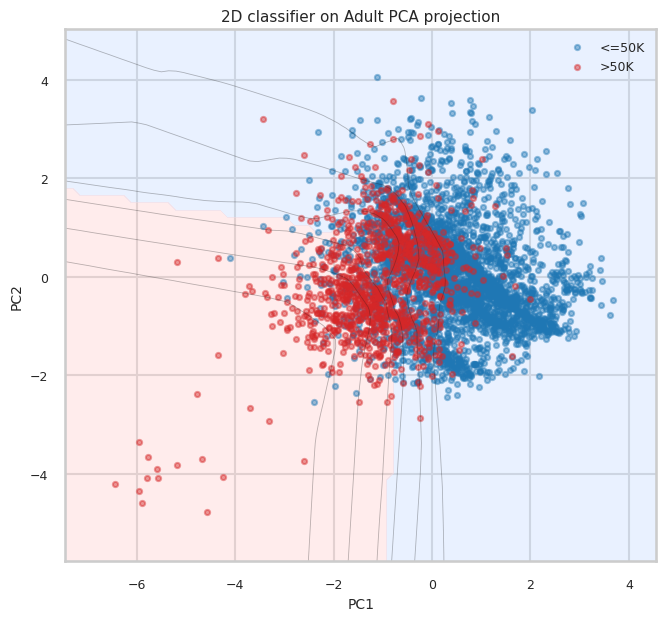

In [5]:
@torch.no_grad()
def predict_np(model, x, device=DEVICE):
    x_t = torch.from_numpy(np.asarray(x, dtype=np.float32)).to(device)
    logits = model(x_t)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = probs.argmax(axis=1)
    return preds, probs


def plot_decision_boundary(model, x, y, title='Classifier decision boundary', grid_step=0.15):
    x_min, x_max = x[:, 0].min() - 1.0, x[:, 0].max() + 1.0
    y_min, y_max = x[:, 1].min() - 1.0, x[:, 1].max() + 1.0
    xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step), np.arange(y_min, y_max, grid_step))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds, probs = predict_np(model, grid)
    zz = preds.reshape(xx.shape)
    conf = probs.max(axis=1).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(7, 7))
    cmap = ListedColormap(['#cfe2ff', '#ffd6d6'])
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], cmap=cmap, alpha=0.45)
    ax.contour(xx, yy, conf, levels=[0.55, 0.70, 0.85], colors='k', linewidths=0.6, alpha=0.30)
    for cls, color, label in [(0, '#1f77b4', '<=50K'), (1, '#d62728', '>50K')]:
        mask = y == cls
        ax.scatter(x[mask, 0], x[mask, 1], s=14, alpha=0.45, c=color, label=label)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(frameon=False, fontsize=9)
    ax.set_aspect('equal')
    fig.tight_layout()
    return fig, ax


plot_decision_boundary(MODEL, X_TEST, Y_TEST_TRUE, title='2D classifier on Adult PCA projection')
plt.show()


## Build CertCF atlases at different `eps_alpha`

Important choices:
- we use **predicted** training labels as support labels, matching current benchmark semantics
- we build the atlas on a **support subset** to keep this notebook diagnostic and tractable

So this notebook is about geometry and coverage trends, not about reproducing the full Adult benchmark.


In [6]:
ALPHAS = [0.25, 0.45, 0.99]
ATLAS_CFG = {
    'norm': 1,
    'distance_norm': 1,
    'lirpa_method': 'backward',
    'batch_size': 256,
    'support_max_per_class': 1000,
}


def stratified_subsample(x: np.ndarray, y: np.ndarray, max_per_class: int, seed: int = SEED):
    rng = np.random.default_rng(seed)
    keep = []
    for cls in sorted(np.unique(y)):
        idx = np.where(y == cls)[0]
        if len(idx) > max_per_class:
            idx = rng.choice(idx, size=max_per_class, replace=False)
        keep.append(np.sort(idx))
    keep = np.concatenate(keep)
    keep = np.sort(keep)
    return x[keep], y[keep], keep


Y_TRAIN_PRED, _ = predict_np(MODEL, X_TRAIN)
X_SUPPORT, Y_SUPPORT, SUPPORT_IDX = stratified_subsample(
    X_TRAIN,
    Y_TRAIN_PRED,
    max_per_class=ATLAS_CFG['support_max_per_class'],
)

print({
    'predicted_train_class_counts': {int(c): int((Y_TRAIN_PRED == c).sum()) for c in np.unique(Y_TRAIN_PRED)},
    'support_shape': tuple(X_SUPPORT.shape),
    'support_class_counts': {int(c): int((Y_SUPPORT == c).sum()) for c in np.unique(Y_SUPPORT)},
})

atlas_bundle = {}
for alpha in ALPHAS:
    ds = TensorDataset(
        torch.from_numpy(X_SUPPORT).float(),
        torch.from_numpy(Y_SUPPORT).long(),
    )
    atlas = CertCFAtlas(
        MODEL,
        ds,
        DEVICE,
        cnn=False,
        norm=ATLAS_CFG['norm'],
        distance_norm=ATLAS_CFG['distance_norm'],
        lirpa_method=ATLAS_CFG['lirpa_method'],
        eps_strategy=NearestOppositeClassClearanceStrategy(alpha=alpha),
        batch_size=ATLAS_CFG['batch_size'],
        default_query_method='nearest_anchor',
        solver_maxiter=500,
    )
    atlas.build(build_unions=True, verbose=True)
    atlas_bundle[alpha] = atlas

print('Built atlases for alphas:', list(atlas_bundle))


{'predicted_train_class_counts': {0: 29365, 1: 6813}, 'support_shape': (2000, 2), 'support_class_counts': {0: 1000, 1: 1000}}
Building certified atlas (eps in [0.005875, 2.223] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:26<00:00, 13.29s/it]


  Building BVH spatial indices...
    Class 0: 1000 polytopes, tree depth 11
    Class 1: 1000 polytopes, tree depth 11
  Building polygon unions...
Done! Total: 2000 polytopes across 2 classes
Building certified atlas (eps in [0.01057, 4.002] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:27<00:00, 13.71s/it]


  Building BVH spatial indices...
    Class 0: 1000 polytopes, tree depth 11
    Class 1: 1000 polytopes, tree depth 11
  Building polygon unions...
Done! Total: 2000 polytopes across 2 classes
Building certified atlas (eps in [0.02326, 8.804] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:27<00:00, 13.63s/it]

  Building BVH spatial indices...
    Class 0: 1000 polytopes, tree depth 11
    Class 1: 1000 polytopes, tree depth 11
  Building polygon unions...
Done! Total: 2000 polytopes across 2 classes
Built atlases for alphas: [0.25, 0.45, 0.99]


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/src/certcf/visualization/plotting.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_classes)


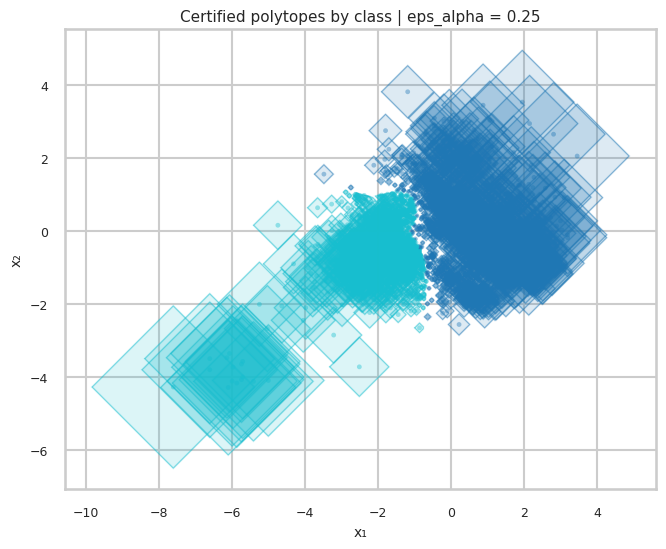

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/src/certcf/visualization/plotting.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_classes)


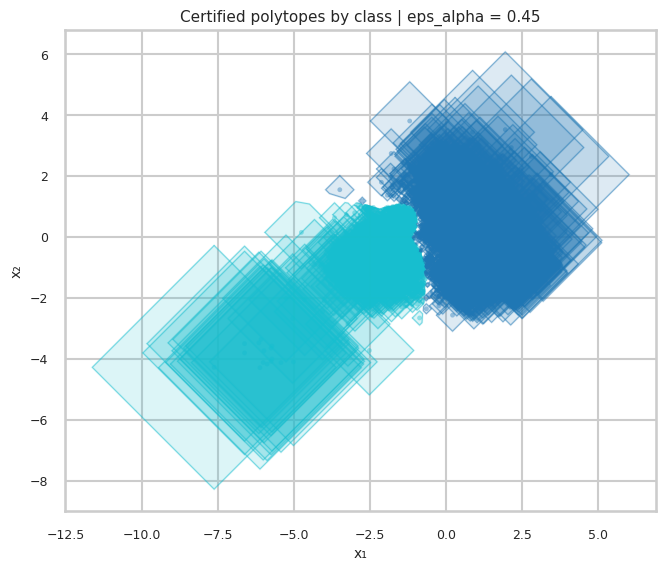

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/src/certcf/visualization/plotting.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, n_classes)


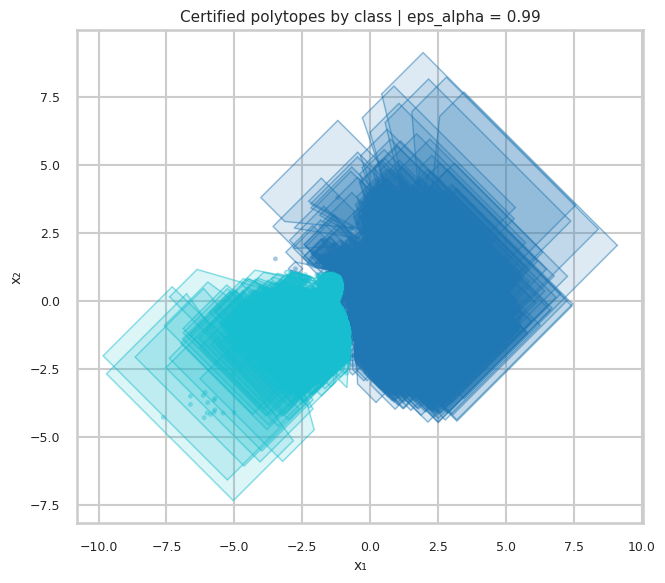

In [7]:
for alpha, atlas in atlas_bundle.items():
    fig, ax = plot_polytopes(
        atlas.bounds,
        eps=0.1,
        n_classes=atlas.n_classes,
        norm=atlas.norm,
        figsize=(7, 7),
    )
    ax.set_title(f'Certified polytopes by class | eps_alpha = {alpha}', fontsize=11)
    plt.show()


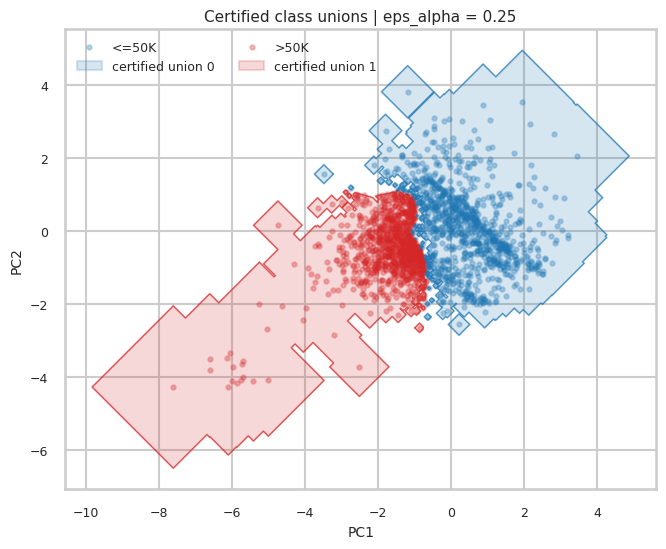

{'max_cross_class_overlap_area': 0.0}


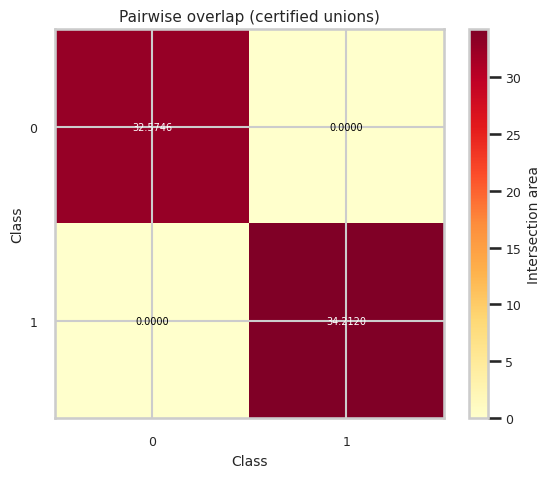

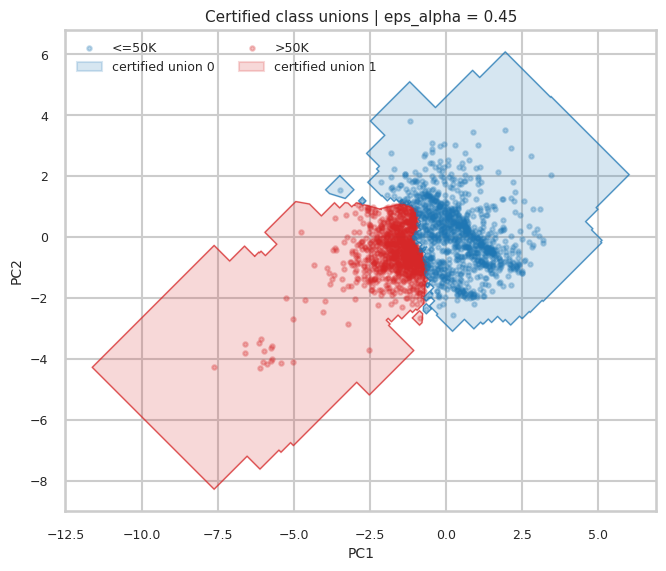

{'max_cross_class_overlap_area': 0.0}


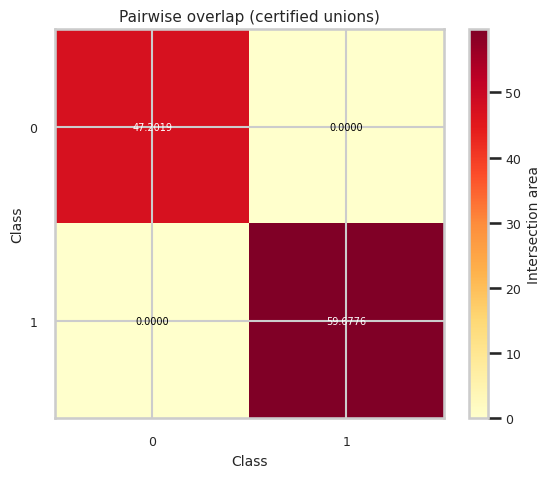

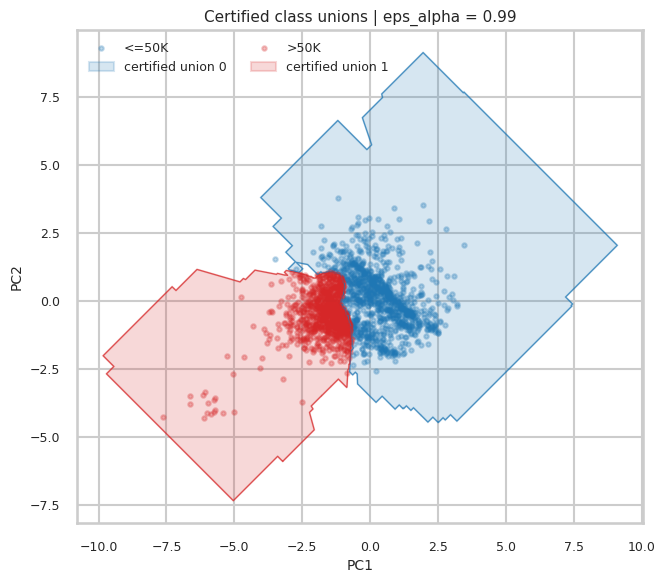

{'max_cross_class_overlap_area': 0.0}


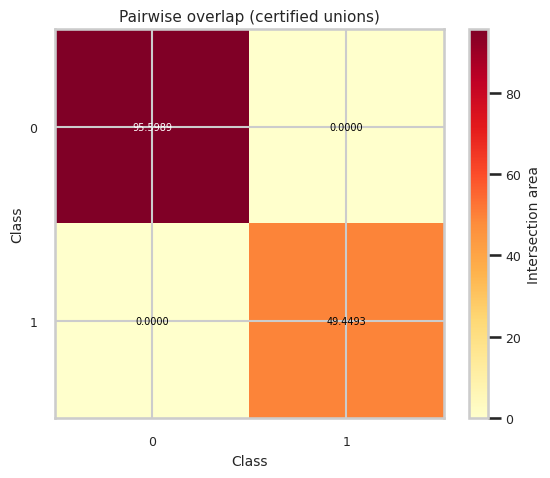

In [8]:
def plot_union_overlay(atlas, x, y, title):
    fig, ax = plt.subplots(figsize=(7, 7))
    colors = {0: '#1f77b4', 1: '#d62728'}
    labels = {0: '<=50K', 1: '>50K'}
    for cls in sorted(np.unique(y)):
        mask = y == cls
        ax.scatter(x[mask, 0], x[mask, 1], s=10, alpha=0.28, c=colors[cls], label=labels[cls])
        geom = atlas.get_class_union(int(cls))
        if not geom.is_empty:
            geoms = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
            for i, g in enumerate(geoms):
                xs, ys = g.exterior.xy
                ax.fill(xs, ys, color=colors[cls], alpha=0.18, label=f'certified union {cls}' if i == 0 else None)
                ax.plot(xs, ys, color=colors[cls], lw=0.9, alpha=0.75)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(frameon=False, ncol=2, fontsize=9)
    ax.set_aspect('equal')
    fig.tight_layout()
    return fig, ax


def certified_overlap_diagnostic(atlas, tol=1e-9):
    overlap_data = compute_overlap_matrix(atlas._class_unions)
    overlap = np.array(overlap_data['overlap'], dtype=np.float64)
    off_diag = overlap.copy()
    np.fill_diagonal(off_diag, 0.0)
    max_cross_overlap = float(off_diag.max(initial=0.0))
    print({'max_cross_class_overlap_area': max_cross_overlap})
    if max_cross_overlap > tol:
        raise RuntimeError(f'Certified unions overlap across classes (area={max_cross_overlap}).')
    return overlap_data


for alpha, atlas in atlas_bundle.items():
    plot_union_overlay(atlas, X_SUPPORT, Y_SUPPORT, title=f'Certified class unions | eps_alpha = {alpha}')
    plt.show()
    overlap_data = certified_overlap_diagnostic(atlas)
    plot_overlap_heatmap(overlap_data)
    plt.show()


## Query examples

We pick a few test points from each predicted class and visualize:
- the query point
- the returned counterfactual
- the connecting segment

This keeps the interpretation parallel to `6.16` while using a real projected dataset.


In [9]:
QUERY_CFG = {
    'method': 'nearest_anchor',
    'query_k_candidates': 3,
    'delta': 0.0,
}


def choose_queries(x, y_pred, max_per_class=3):
    chosen = []
    for cls in sorted(np.unique(y_pred)):
        idx = np.where(y_pred == cls)[0][:max_per_class]
        chosen.extend(idx.tolist())
    return chosen


Y_TEST_PRED, _ = predict_np(MODEL, X_TEST)
QUERY_IDXS = choose_queries(X_TEST, Y_TEST_PRED, max_per_class=3)
print('query_idxs', QUERY_IDXS)


query_idxs [0, 1, 2, 8, 16, 21]


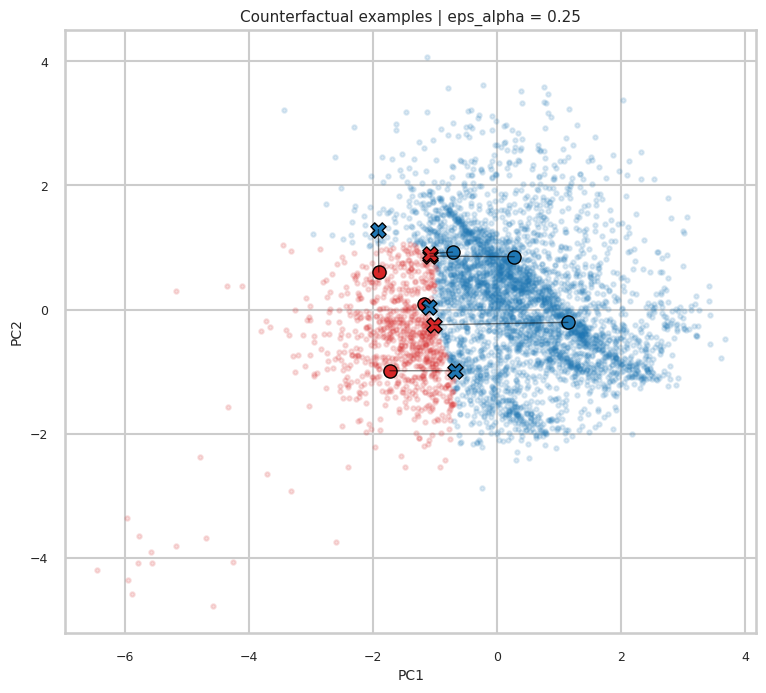

[{'query_idx': 0,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 1.3633135685350033,
  'n_qp_solved': 3},
 {'query_idx': 1,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 0.3864858000410034,
  'n_qp_solved': 3},
 {'query_idx': 2,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 2.198654434432272,
  'n_qp_solved': 3},
 {'query_idx': 8,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.6925139832123883,
  'n_qp_solved': 3},
 {'query_idx': 16,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 1.0528693346667741,
  'n_qp_solved': 3},
 {'query_idx': 21,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.1287207723570215,
  'n_qp_solved': 3}]

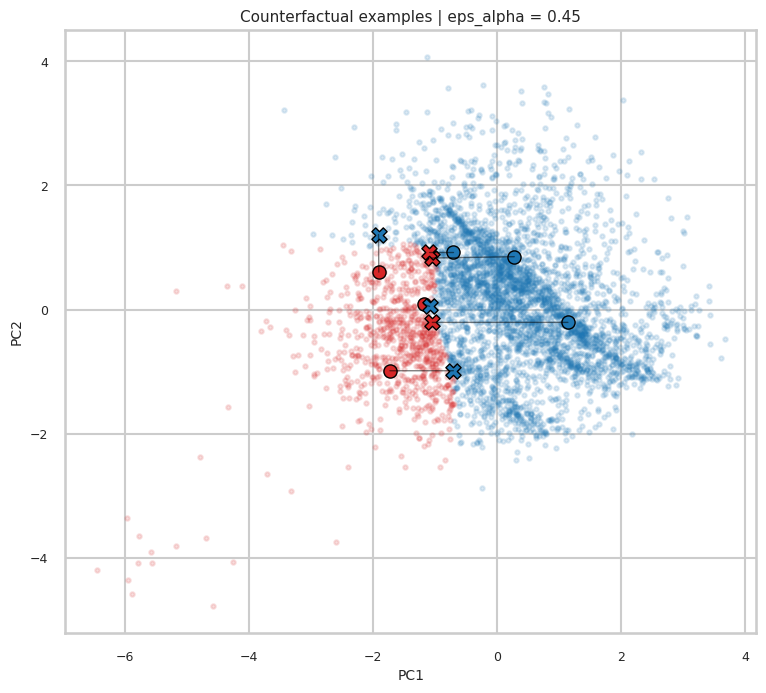

[{'query_idx': 0,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 1.3473374168926617,
  'n_qp_solved': 3},
 {'query_idx': 1,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 0.37138982656564723,
  'n_qp_solved': 3},
 {'query_idx': 2,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 2.185554353418327,
  'n_qp_solved': 3},
 {'query_idx': 8,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.6104877782216498,
  'n_qp_solved': 3},
 {'query_idx': 16,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 1.0239243773627438,
  'n_qp_solved': 3},
 {'query_idx': 21,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.12249732281150107,
  'n_qp_solved': 3}]

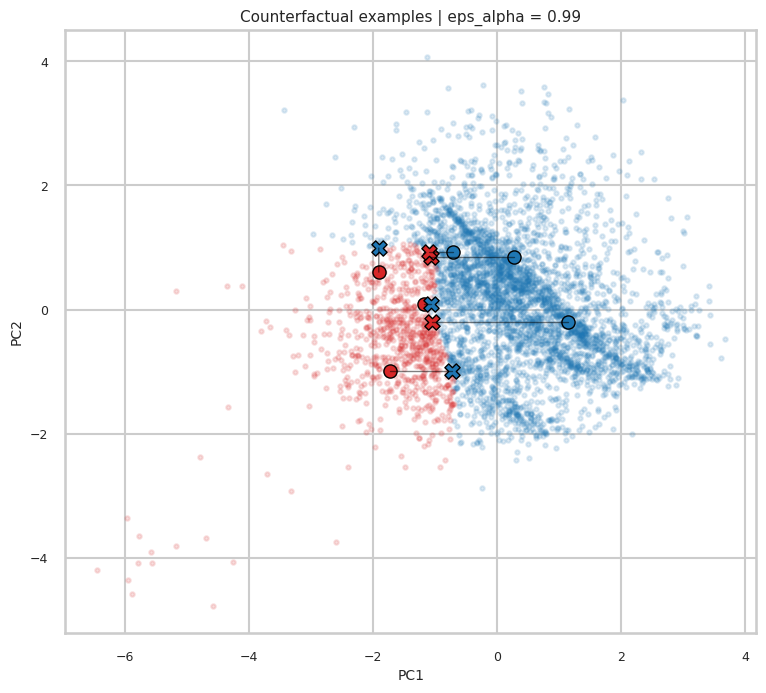

[{'query_idx': 0,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 1.3339548440742726,
  'n_qp_solved': 3},
 {'query_idx': 1,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 0.3712451147000888,
  'n_qp_solved': 3},
 {'query_idx': 2,
  'y_pred': 0,
  'target': 1,
  'success': True,
  'distance': 2.185282569483549,
  'n_qp_solved': 3},
 {'query_idx': 8,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.389017019306786,
  'n_qp_solved': 3},
 {'query_idx': 16,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.99897333553761,
  'n_qp_solved': 3},
 {'query_idx': 21,
  'y_pred': 1,
  'target': 0,
  'success': True,
  'distance': 0.1140457964512532,
  'n_qp_solved': 3}]

In [10]:
def plot_counterfactual_examples(atlas, x_test, y_test, query_indices, title):
    fig, ax = plt.subplots(figsize=(8, 8))
    colors = {0: '#1f77b4', 1: '#d62728'}

    y_pred_test, _ = predict_np(MODEL, x_test)
    for cls in sorted(np.unique(y_pred_test)):
        mask = y_pred_test == cls
        ax.scatter(x_test[mask, 0], x_test[mask, 1], s=10, alpha=0.15, c=colors[cls])

    rows = []
    for idx in query_indices:
        xq = x_test[idx]
        yq = int(y_pred_test[idx])
        target = 1 - yq
        result = atlas.find_counterfactual(
            xq,
            target_class=target,
            method=QUERY_CFG['method'],
            delta=QUERY_CFG['delta'],
            query_k_candidates=QUERY_CFG['query_k_candidates'],
        )
        rows.append({
            'query_idx': idx,
            'y_pred': yq,
            'target': target,
            'success': bool(result.success),
            'distance': float(result.distance),
            'n_qp_solved': int(result.n_qp_solved),
        })
        ax.scatter([xq[0]], [xq[1]], c=colors[yq], s=90, marker='o', edgecolors='black', linewidths=1.0)
        if result.x_cf is not None and np.all(np.isfinite(result.x_cf)):
            xcf = np.asarray(result.x_cf)
            ax.scatter([xcf[0]], [xcf[1]], c=colors[target], s=120, marker='X', edgecolors='black', linewidths=1.0)
            ax.plot([xq[0], xcf[0]], [xq[1], xcf[1]], color='black', alpha=0.5, lw=1.0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_aspect('equal')
    fig.tight_layout()
    return fig, ax, rows


for alpha, atlas in atlas_bundle.items():
    fig, ax, rows = plot_counterfactual_examples(
        atlas,
        X_TEST,
        Y_TEST_TRUE,
        QUERY_IDXS,
        title=f'Counterfactual examples | eps_alpha = {alpha}',
    )
    plt.show()
    display(rows)


## Questions to ask after running

Use this notebook to inspect:
- Does larger `eps_alpha` visibly expand certified coverage in the PCA plane?
- Are the certified unions still disjoint across classes?
- Do some Adult regions remain thin or disconnected even in 2D?
- Are returned counterfactuals getting meaningfully shorter with larger `eps_alpha`?
- Would more support points help more than larger `eps_alpha` in this projected setting?

This is a diagnostic notebook, not a replacement for the full Adult benchmark.
